In [52]:
"""In this notebook, the goal is to explore and understand the structure and characteristics of the dataset
 before building any models. This includes visually inspecting images and comparing how they differ across cameras, 
 individuals, and processing methods. We will examine the distribution of labels (1–10) to check for imbalance, and 
 look for any inconsistencies or anomalies in the data such as mislabeled or corrupted images. Additionally, we will 
 begin to develop intuition about how image properties (e.g., brightness, contrast) may relate to the labels. This step 
 is critical for identifying potential sources of variability (camera differences, human differences, raw vs processed images) 
 and ensuring the data is clean, consistent, and suitable for modeling."""

'In this notebook, the goal is to explore and understand the structure and characteristics of the dataset\n before building any models. This includes visually inspecting images and comparing how they differ across cameras, \n individuals, and processing methods. We will examine the distribution of labels (1–10) to check for imbalance, and \n look for any inconsistencies or anomalies in the data such as mislabeled or corrupted images. Additionally, we will \n begin to develop intuition about how image properties (e.g., brightness, contrast) may relate to the labels. This step \n is critical for identifying potential sources of variability (camera differences, human differences, raw vs processed images) \n and ensuring the data is clean, consistent, and suitable for modeling.'

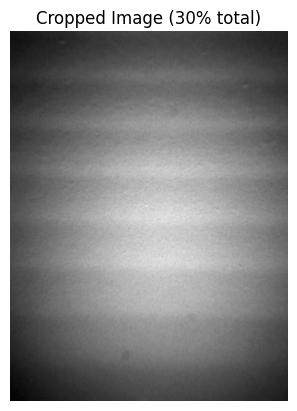

8081920
(3280, 2464)
(2464, 3280)
(2464, 3280)
527.903625096044
526.1715741068416
528.601053932742


In [83]:
# load as RGB (maybe I should just load as grayscale) image using pillow package - just try with the original images first

from PIL import Image
import os


img = Image.open("../data/raw/1/Leveling-1_GS-25-130_0degrees (1).png").convert("L")
img2 = Image.open("../data/raw/1/Leveling-1_GS-25-130_0degrees (2).png").convert("L")
img3 = Image.open("../data/raw/3/Leveling-3_GS-25-100 (1).png").convert("L")

img.show()

import numpy as np
import matplotlib.pyplot as plt

img_array = np.array(img)

h, w = img_array.shape

# amount to remove (15% from each side)
crop_h = int(0.15 * h)
crop_w = int(0.15 * w)

img_cropped = img_array[
    crop_h : h - crop_h,   # vertical (top + bottom)
    crop_w : w - crop_w    # horizontal (left + right)
]

# show image
import matplotlib.pyplot as plt

plt.imshow(img_cropped, cmap='gray')
plt.title("Cropped Image (30% total)")
plt.axis('off')
plt.show()

import numpy as np
img_array = np.array(img)
img_array2 = np.array(img2)
img_array3 = np.array(img3)

num_pixels = img_array.size
print(num_pixels)
print(img_array.shape)
print(img_array2.shape)
print(img_array3.shape)



# now we want to compute image-derived metrics 
# some image derived metrics: MSE and PSNR
# MSE is average of the squared differences between two images (pixel-by-pixel)
#here we are looking for a model that takes an image an outputs an average human rating

#we want to ask how much do pixels deviate from a perfectly uniform version of this image
# so we can take the mean of the image, and then computer the MSE between the image and the average


def compute_mse(img_array): #this function takes an array and computes the MSE
    mean_val = np.mean(img_array)
    mse = np.mean((img_array - mean_val) ** 2)
    return mse

mse1 = compute_mse(img_array)
mse2 = compute_mse(img_array2)
mse3 = compute_mse(img_array3)

print(mse1) #leveling 1
print(mse2) #leveling 1
print(mse3) #leveling 3


In [54]:
#based on these results, we can't see the pattern we want to, so lets create a scatter plot of all the images and see if we get a linear trend
#color the points by the leveling score


# load in all our images and labels into a list of tuples (label, filename, numpy array) so we can easily access them for plotting and modeling
# and also store the mse

import os
import numpy as np
from PIL import Image

def compute_mse(img_array):
    mean_val = np.mean(img_array)
    mse = np.mean((img_array - mean_val) ** 2)
    return mse

raw_data_dir = "../data/raw"

images = []   # list of (label, filename, numpy array, mse)

for label_folder in sorted(os.listdir(raw_data_dir), key=lambda x: int(x)):
    folder_path = os.path.join(raw_data_dir, label_folder)
    if not os.path.isdir(folder_path):
        continue
    
    label = int(label_folder)
    
    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(".png"):
            img_path = os.path.join(folder_path, filename)
            
            img = Image.open(img_path).convert("L")
            img_array = np.array(img)
            
            mse = compute_mse(img_array)
            
            images.append((label, filename, img_array, mse))

print(f"Loaded {len(images)} images")
print(f"Example — label: {images[0][0]}, file: {images[0][1]}, MSE: {images[0][3]}")


Loaded 312 images
Example — label: 1, file: Leveling-1_GS-25-130_0degrees (1).png, MSE: 527.903625096044


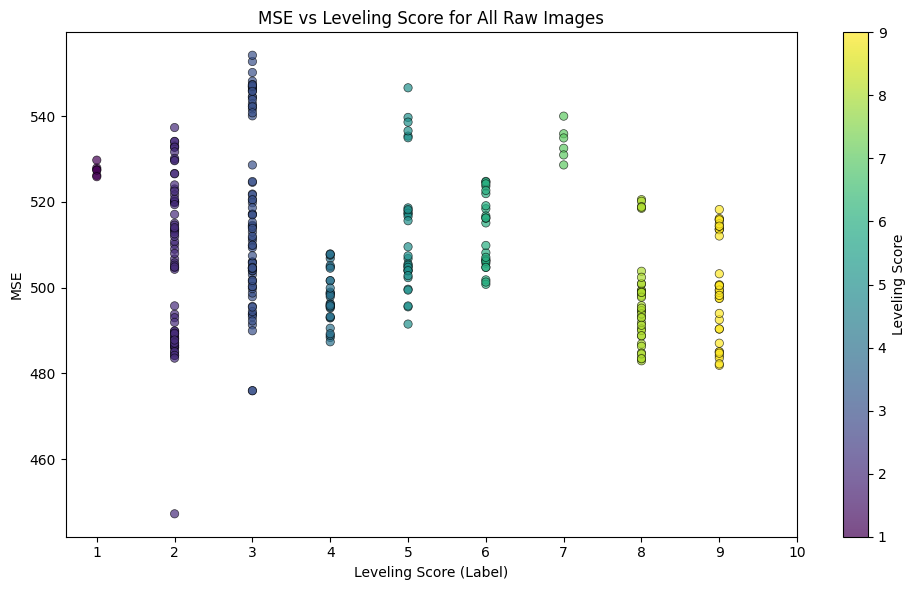

In [55]:
# create a scatter plot of MSE vs leveling score for all raw images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]
mses   = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, mses, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("MSE")
plt.title("MSE vs Leveling Score for All Raw Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


Average MSE by leveling score:
Label 1: 527.421
Label 2: 506.772
Label 3: 517.494
Label 4: 497.798
Label 5: 513.204
Label 6: 512.775
Label 7: 533.805
Label 8: 496.919
Label 9: 500.366


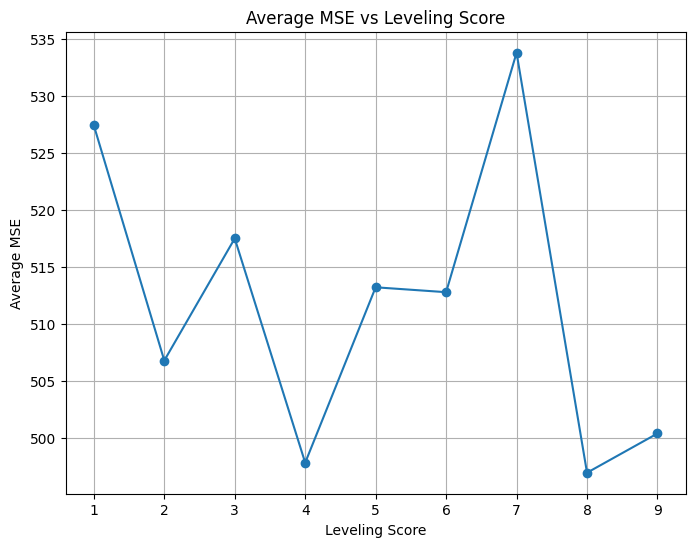

In [56]:
# compute the average MSE for each leveling score (1-10)

import numpy as np

avg_mse_by_label = {}
for label in range(1, 11):
    label_mses = [item[3] for item in images if item[0] == label]
    if len(label_mses) > 0:
        avg_mse_by_label[label] = float(np.mean(label_mses))

print("Average MSE by leveling score:")
for label in sorted(avg_mse_by_label):
    print(f"Label {label}: {avg_mse_by_label[label]:.3f}")


# plot the average MSE by leveling score as a line plot
import matplotlib.pyplot as plt

# sort labels to keep order correct
labels = sorted(avg_mse_by_label.keys())
avg_mse_values = [avg_mse_by_label[label] for label in labels]

plt.figure(figsize=(8, 6))

plt.plot(labels, avg_mse_values, marker='o', linestyle='-')

plt.xlabel("Leveling Score")
plt.ylabel("Average MSE")
plt.title("Average MSE vs Leveling Score")

plt.xticks(labels)
plt.grid(True)

plt.show()


In [57]:
# based on the above graph we can see that MSE isnt capturing what humans see, so we need to think about a different metric that we could use
# one metric we can try is edge strength -> measures how strong the changes in brightness are across the image

from scipy import ndimage
import numpy as np

#function that takes an numpy array and computes the edge strength using the Sobel operator
def compute_edge_strength(img_array):
    dx = ndimage.sobel(img_array, axis=1)   # horizontal direction differences
    edge_strength = np.mean(np.abs(dx))
    return edge_strength

# compute edge strength for all images and add to our list of tuples called images
images_with_edge = []

for item in images:
    label, filename, img_array, mse = item[:4]
    edge_strength = compute_edge_strength(img_array)
    images_with_edge.append((label, filename, img_array, mse, edge_strength))

images = images_with_edge

print(f"Updated {len(images)} images with edge strength")
print(f"Example tuple format: (label, filename, img_array, mse, edge_strength)")
print(f"Example edge strength: {images[0][4]:.3f}")



Updated 312 images with edge strength
Example tuple format: (label, filename, img_array, mse, edge_strength)
Example edge strength: 102.435


In [58]:
print(images[0])

(1, 'Leveling-1_GS-25-130_0degrees (1).png', array([[24, 24, 24, ..., 34, 34, 34],
       [24, 24, 24, ..., 33, 33, 34],
       [24, 24, 24, ..., 33, 33, 33],
       ...,
       [31, 31, 31, ..., 38, 37, 37],
       [31, 31, 31, ..., 38, 37, 37],
       [33, 31, 31, ..., 39, 38, 38]], shape=(3280, 2464), dtype=uint8), np.float64(527.903625096044), np.float64(102.4349946547355))


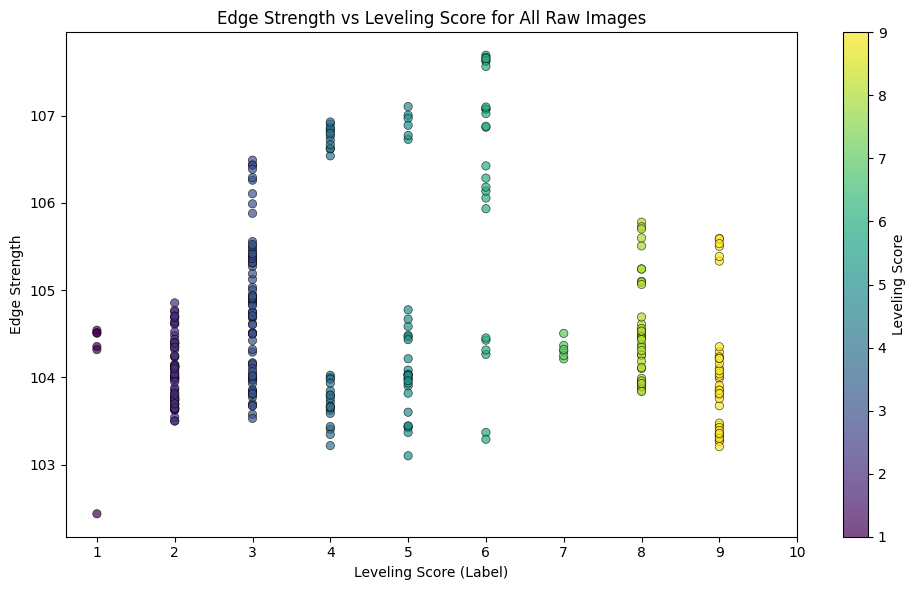

In [59]:
# create a scatter plot of the edge strength vs leveling score for all raw images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]

# If edge strength is already stored in tuple index 4, use it.
# Otherwise compute it from the image array at tuple index 2.
edge_strengths = []
for item in images:
    if len(item) >= 5:
        edge_strengths.append(item[4])
    else:
        edge_strengths.append(compute_edge_strength(item[2]))

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    labels,
    edge_strengths,
    c=labels,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
)

plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Edge Strength")
plt.title("Edge Strength vs Leveling Score for All Raw Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [ ]:
# we can see from the figure above that edge strength also isnt capturing what humans see, so maybe lets try using the flat images

import sys

sys.path.append(os.path.abspath(".."))

from src.data import load_images

images = load_images("flat") #this gives us our images as a list of tuples (label, filename, numpy array) 

Loaded 312 images from 'flat'


In [63]:
# continue from above step, we want to compute MSE on the flat images

#compute MSE and add it to list of images
from src.features import append_mse_to_images

images = append_mse_to_images(images)


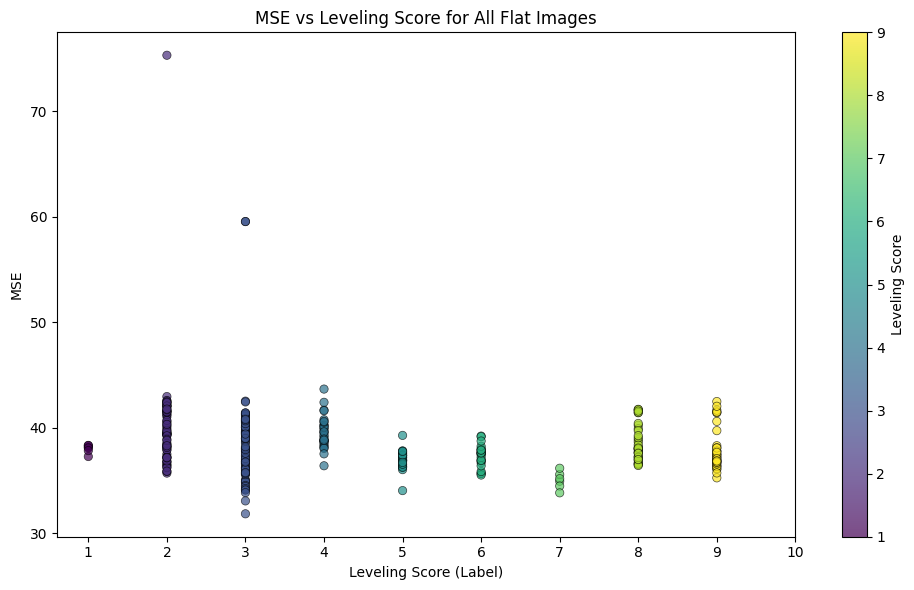

In [ ]:

# create scatter plot of MSE vs leveling score for all flat images, color the points by the leveling score

import matplotlib.pyplot as plt

labels = [item[0] for item in images]
mses   = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, mses, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("MSE")
plt.title("MSE vs Leveling Score for All Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [ ]:
# based on the above graph, we can see MSE using the flat images wont work either

In [ ]:
# now lets try the flat images with the edge strength metric instead of MSE and see if that captures what humans see better than the raw images with MSE or edge strength
images = load_images("flat")

from src.features import compute_edge_strength
from src.features import append_edge_strength_to_images
images = append_edge_strength_to_images(images)


Loaded 312 images from 'flat'
(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8))
(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8), np.float64(111.921648321191))


(1, 'Leveling-1_GS-25-130_0degrees_flat (1).png', array([[103, 102,  97, ..., 102, 102, 106],
       [103,  99,  97, ..., 102, 102, 106],
       [103,  98,  98, ..., 102, 102, 106],
       ...,
       [ 94,  94,  95, ..., 111, 112, 112],
       [ 94,  94,  96, ..., 112, 114, 114],
       [ 94,  94,  94, ..., 113, 114, 122]],
      shape=(2464, 3280), dtype=uint8), np.float64(111.921648321191))


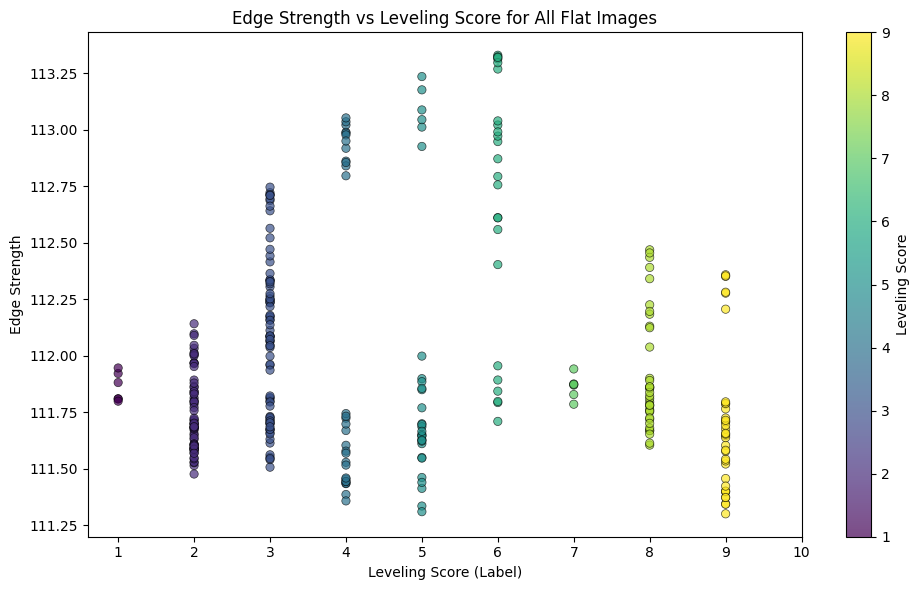

In [75]:
# create scatter plot
import matplotlib.pyplot as plt

print(images[0]) # check the format of the images list to make sure we have the edge strength in the right place

labels = [item[0] for item in images]
edge_strengths = [item[3] for item in images]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, edge_strengths, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Edge Strength")
plt.title("Edge Strength vs Leveling Score for All Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [77]:
# we can see again for flat and raw images, edge strength and MSE arent capturing what humans see
# try some different metrics and look at correlation coefficient based on the grayscale raw images

images = load_images("raw")


Loaded 312 images from 'raw'


In [76]:
# compute several image metrics and show correlation with label

import numpy as np
from scipy import ndimage
from scipy.stats import pearsonr, spearmanr

# If images is not loaded yet, load raw images.
if "images" not in globals() or len(images) == 0:
    images = load_images("raw")


def compute_metrics(img_array):
    arr = img_array.astype(np.float32)

    mean_intensity = float(np.mean(arr))
    std_intensity = float(np.std(arr))
    rms_contrast = std_intensity

    # MSE to image mean (same concept you already used)
    mean_val = np.mean(arr)
    mse_to_mean = float(np.mean((arr - mean_val) ** 2))

    # Edge/gradient based metrics
    sobel_x = ndimage.sobel(arr, axis=1)
    sobel_y = ndimage.sobel(arr, axis=0)
    grad_mag = np.hypot(sobel_x, sobel_y)

    edge_strength = float(np.mean(np.abs(sobel_x)))
    tenengrad = float(np.mean(grad_mag ** 2))

    # Focus/texture metric
    lap = ndimage.laplace(arr)
    laplacian_var = float(np.var(lap))

    # Entropy from 256-bin histogram
    hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    entropy = float(-np.sum(hist * np.log2(hist)))

    return {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "rms_contrast": rms_contrast,
        "mse_to_mean": mse_to_mean,
        "edge_strength": edge_strength,
        "tenengrad": tenengrad,
        "laplacian_var": laplacian_var,
        "entropy": entropy,
    }


labels = np.array([item[0] for item in images], dtype=np.float32)

metric_names = [
    "mean_intensity",
    "std_intensity",
    "rms_contrast",
    "mse_to_mean",
    "edge_strength",
    "tenengrad",
    "laplacian_var",
    "entropy",
]

metric_values = {name: [] for name in metric_names}
for item in images:
    metrics = compute_metrics(item[2])
    for name in metric_names:
        metric_values[name].append(metrics[name])

print("Correlation with label (higher absolute value means stronger monotonic/linear relation):")
print("-" * 84)
print(f"{'Metric':<18} {'Pearson r':>12} {'p-value':>12} {'Spearman rho':>14} {'p-value':>12}")
print("-" * 84)

for name in metric_names:
    vals = np.array(metric_values[name], dtype=np.float32)
    pr, pp = pearsonr(labels, vals)
    sr, sp = spearmanr(labels, vals)
    print(f"{name:<18} {pr:>12.3f} {pp:>12.3g} {sr:>14.3f} {sp:>12.3g}")


Correlation with label (higher absolute value means stronger monotonic/linear relation):
------------------------------------------------------------------------------------
Metric                Pearson r      p-value   Spearman rho      p-value
------------------------------------------------------------------------------------
mean_intensity           -0.300     6.25e-08         -0.283     3.79e-07
std_intensity            -0.186     0.000985         -0.255     5.13e-06
rms_contrast             -0.186     0.000985         -0.255     5.13e-06
mse_to_mean              -0.180      0.00141         -0.255     5.13e-06
edge_strength            -0.050        0.375         -0.023         0.69
tenengrad                -0.033        0.556         -0.035        0.539
laplacian_var            -0.203     0.000316         -0.185      0.00101
entropy                  -0.467     2.47e-18         -0.583     8.96e-30


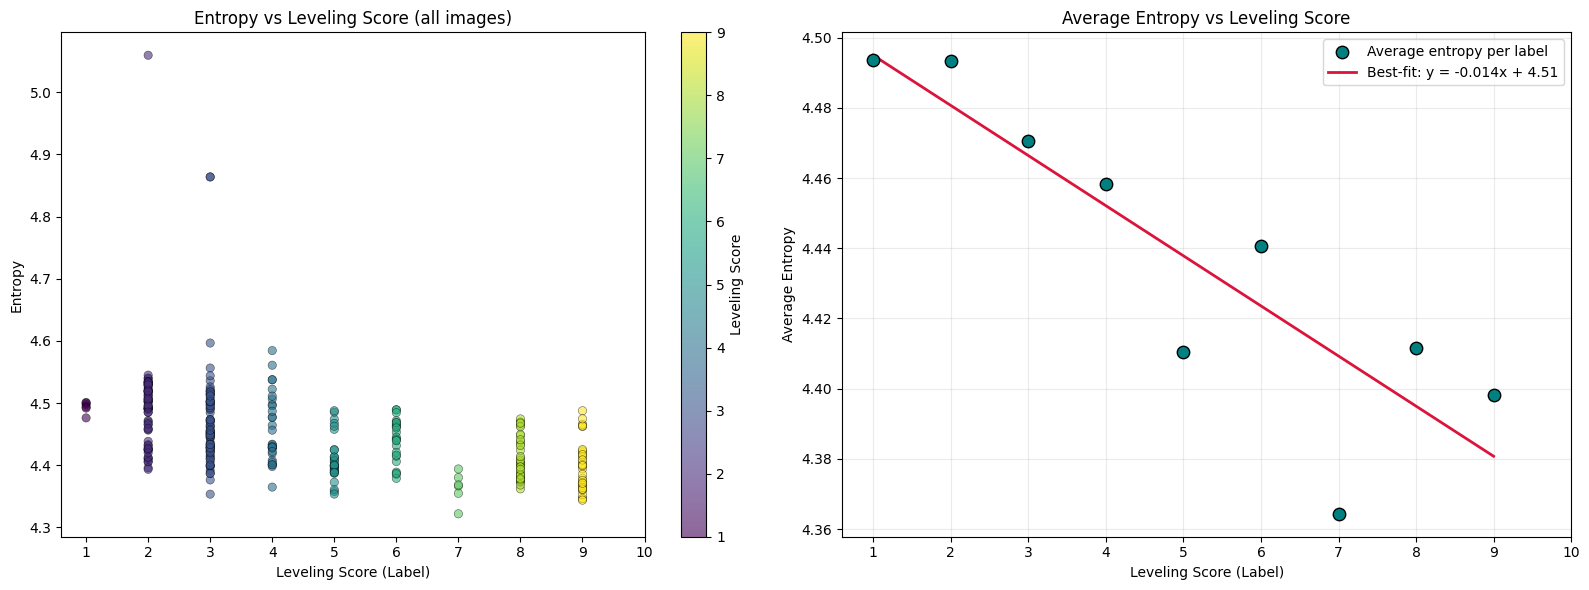

Pearson r:    -0.467  (p=2.47e-18)
Spearman rho: -0.583  (p=8.96e-30)


In [78]:
# visualize entropy vs label: scatter plot of every image + average per label

import matplotlib.pyplot as plt
import numpy as np

entropies = np.array(metric_values["entropy"])

# average entropy per label
avg_entropy_by_label = {}
for lbl in range(1, 11):
    vals = entropies[labels == lbl]
    if len(vals) > 0:
        avg_entropy_by_label[lbl] = float(np.mean(vals))

x_avg = np.array(sorted(avg_entropy_by_label.keys()))
y_avg = np.array([avg_entropy_by_label[l] for l in x_avg])

# best-fit line through the averages
m, b = np.polyfit(x_avg, y_avg, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: all points ---
sc = axes[0].scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.6, edgecolors="k", linewidths=0.4)
plt.colorbar(sc, ax=axes[0], label="Leveling Score")
axes[0].set_xlabel("Leveling Score (Label)")
axes[0].set_ylabel("Entropy")
axes[0].set_title("Entropy vs Leveling Score (all images)")
axes[0].set_xticks(range(1, 11))

# --- right: average per label + best-fit line ---
axes[1].scatter(x_avg, y_avg, s=80, color="teal", edgecolors="black", zorder=3, label="Average entropy per label")
axes[1].plot(x_avg, m * x_avg + b, color="crimson", linewidth=2, label=f"Best-fit: y = {m:.3f}x + {b:.2f}")
axes[1].set_xlabel("Leveling Score (Label)")
axes[1].set_ylabel("Average Entropy")
axes[1].set_title("Average Entropy vs Leveling Score")
axes[1].set_xticks(range(1, 11))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr, spearmanr
pr, pp = pearsonr(labels, entropies)
sr, sp = spearmanr(labels, entropies)
print(f"Pearson r:    {pr:.3f}  (p={pp:.3g})")
print(f"Spearman rho: {sr:.3f}  (p={sp:.3g})")


In [93]:
# now lets try to crop the images to see if that helps the metrics
import sys
import importlib

sys.path.append(os.path.abspath(".."))

import src.data as data_module
importlib.reload(data_module)

images = data_module.load_images_optional_crop("flat", crop_fraction=0.40)
print(f"Cropped image shape: {images[0][2].shape}")

#now lets rerun the metrics on the cropped images and see if we get a better correlation with the labels

# compute several image metrics and show correlation with label

import numpy as np
from scipy import ndimage
from scipy.stats import pearsonr, spearmanr


def compute_metrics(img_array):
    arr = img_array.astype(np.float32)

    mean_intensity = float(np.mean(arr))
    std_intensity = float(np.std(arr))
    rms_contrast = std_intensity

    # MSE to image mean (same concept you already used)
    mean_val = np.mean(arr)
    mse_to_mean = float(np.mean((arr - mean_val) ** 2))

    # Edge/gradient based metrics
    sobel_x = ndimage.sobel(arr, axis=1)
    sobel_y = ndimage.sobel(arr, axis=0)
    grad_mag = np.hypot(sobel_x, sobel_y)

    edge_strength = float(np.mean(np.abs(sobel_x)))
    tenengrad = float(np.mean(grad_mag ** 2))

    # Focus/texture metric
    lap = ndimage.laplace(arr)
    laplacian_var = float(np.var(lap))

    # Entropy from 256-bin histogram
    hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    entropy = float(-np.sum(hist * np.log2(hist)))

    return {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "rms_contrast": rms_contrast,
        "mse_to_mean": mse_to_mean,
        "edge_strength": edge_strength,
        "tenengrad": tenengrad,
        "laplacian_var": laplacian_var,
        "entropy": entropy,
    }


labels = np.array([item[0] for item in images], dtype=np.float32)

metric_names = [
    "mean_intensity",
    "std_intensity",
    "rms_contrast",
    "mse_to_mean",
    "edge_strength",
    "tenengrad",
    "laplacian_var",
    "entropy",
]

metric_values = {name: [] for name in metric_names}
for item in images:
    metrics = compute_metrics(item[2])
    for name in metric_names:
        metric_values[name].append(metrics[name])

print("Correlation with label (higher absolute value means stronger monotonic/linear relation):")
print("-" * 84)
print(f"{'Metric':<18} {'Pearson r':>12} {'p-value':>12} {'Spearman rho':>14} {'p-value':>12}")
print("-" * 84)

for name in metric_names:
    vals = np.array(metric_values[name], dtype=np.float32)
    pr, pp = pearsonr(labels, vals)
    sr, sp = spearmanr(labels, vals)
    print(f"{name:<18} {pr:>12.3f} {pp:>12.3g} {sr:>14.3f} {sp:>12.3g}")


Loaded 312 images from 'flat' (cropping=ON)
Cropped image shape: (1480, 1968)
Correlation with label (higher absolute value means stronger monotonic/linear relation):
------------------------------------------------------------------------------------
Metric                Pearson r      p-value   Spearman rho      p-value
------------------------------------------------------------------------------------
mean_intensity           -0.266     1.93e-06         -0.235     2.79e-05
std_intensity            -0.633      2.1e-36         -0.643     7.35e-38
rms_contrast             -0.633      2.1e-36         -0.643     7.35e-38
mse_to_mean              -0.623     5.29e-35         -0.643     7.35e-38
edge_strength            -0.009         0.88          0.010        0.859
tenengrad                -0.045        0.426         -0.030        0.599
laplacian_var            -0.175      0.00195         -0.130       0.0214
entropy                  -0.670     4.56e-42         -0.652     4.33e-39


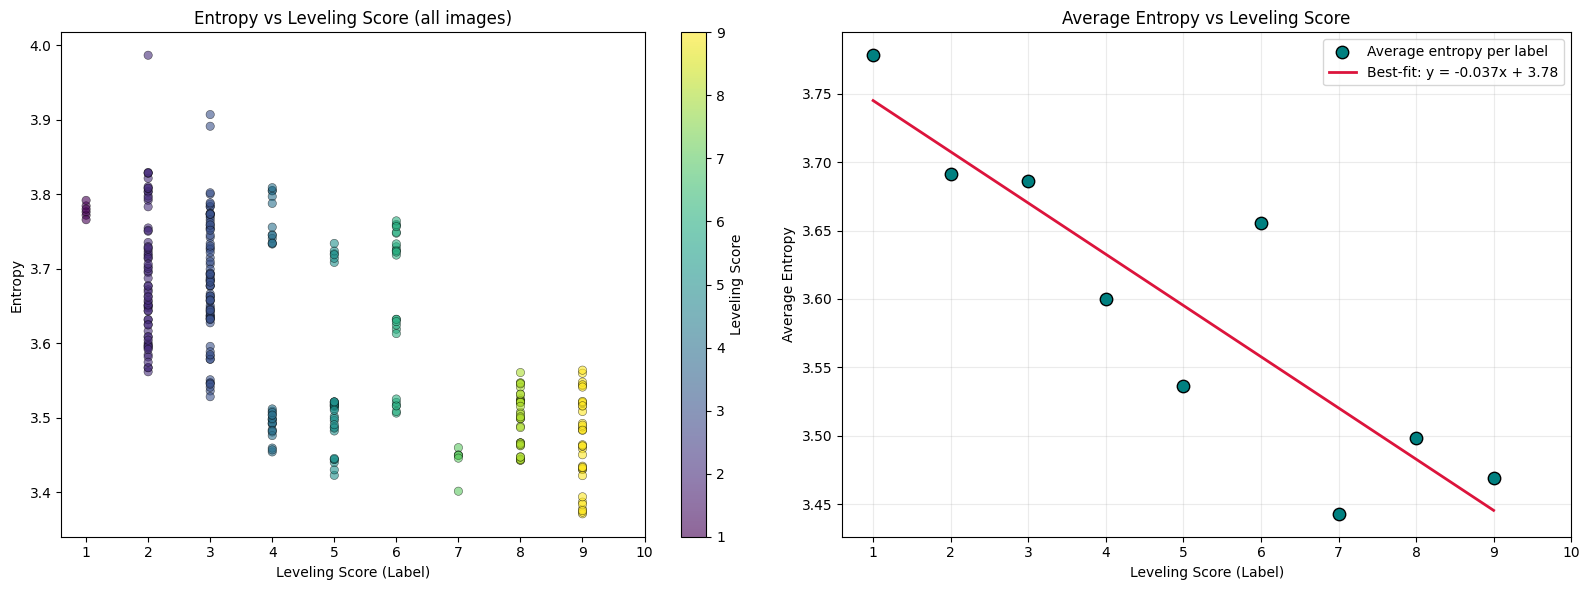

Pearson r:    -0.670  (p=4.56e-42)
Spearman rho: -0.652  (p=4.33e-39)


In [94]:
# visualize entropy vs label: scatter plot of every image + average per label

import matplotlib.pyplot as plt
import numpy as np

entropies = np.array(metric_values["entropy"])

# average entropy per label
avg_entropy_by_label = {}
for lbl in range(1, 11):
    vals = entropies[labels == lbl]
    if len(vals) > 0:
        avg_entropy_by_label[lbl] = float(np.mean(vals))

x_avg = np.array(sorted(avg_entropy_by_label.keys()))
y_avg = np.array([avg_entropy_by_label[l] for l in x_avg])

# best-fit line through the averages
m, b = np.polyfit(x_avg, y_avg, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: all points ---
sc = axes[0].scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.6, edgecolors="k", linewidths=0.4)
plt.colorbar(sc, ax=axes[0], label="Leveling Score")
axes[0].set_xlabel("Leveling Score (Label)")
axes[0].set_ylabel("Entropy")
axes[0].set_title("Entropy vs Leveling Score (all images)")
axes[0].set_xticks(range(1, 11))

# --- right: average per label + best-fit line ---
axes[1].scatter(x_avg, y_avg, s=80, color="teal", edgecolors="black", zorder=3, label="Average entropy per label")
axes[1].plot(x_avg, m * x_avg + b, color="crimson", linewidth=2, label=f"Best-fit: y = {m:.3f}x + {b:.2f}")
axes[1].set_xlabel("Leveling Score (Label)")
axes[1].set_ylabel("Average Entropy")
axes[1].set_title("Average Entropy vs Leveling Score")
axes[1].set_xticks(range(1, 11))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr, spearmanr
pr, pp = pearsonr(labels, entropies)
sr, sp = spearmanr(labels, entropies)
print(f"Pearson r:    {pr:.3f}  (p={pp:.3g})")
print(f"Spearman rho: {sr:.3f}  (p={sp:.3g})")


Loaded 312 images from 'flat' (cropping=ON)


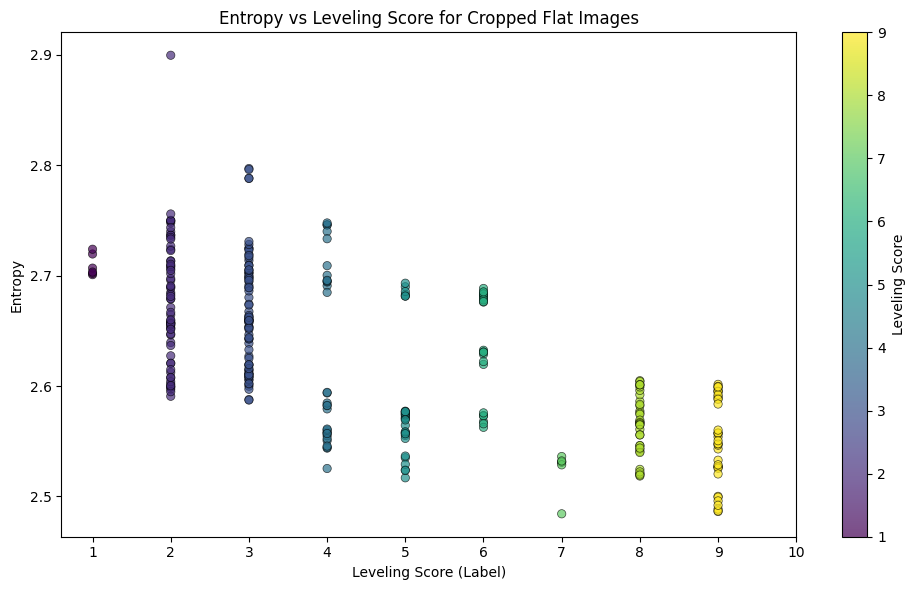

In [5]:
# try the pipeline using flat images, .30% cropped

import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))

from src.data import load_images_optional_crop
from src.features import append_entropy_to_images


#load images
images = load_images_optional_crop("flat", crop_fraction=0.30)


#compute entropy of the images and add to the list of tuples
images = append_entropy_to_images(images)

#plot entropy vs label for the cropped flat images
import matplotlib.pyplot as plt
labels = [item[0] for item in images]
entropies = [item[3] for item in images]
plt.figure(figsize=(10, 6))
scatter = plt.scatter(labels, entropies, c=labels, cmap="viridis", alpha=0.7, edgecolors="k", linewidths=0.5)
plt.colorbar(scatter, label="Leveling Score")
plt.xlabel("Leveling Score (Label)")
plt.ylabel("Entropy")
plt.title("Entropy vs Leveling Score for Cropped Flat Images")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


In [7]:
# we then need to break the data into an 80/20 train test split (could do cross validation here and make sure class
#ratios are the same)


import numpy as np

X = np.array([[item[3]] for item in images])  # entropy as feature
y = np.array([item[0] for item in images])    # labels (1–9)


# get the data into an 80/20 train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,       # THIS is what keeps classes balanced
    random_state=42   # ensures reproducibility
)

#train the model
# we should use a linear regression model from sklearn (from sklearn.linear_model import LinearRegression)

from sklearn.linear_model import LinearRegression

# create model
model = LinearRegression()

# train (fit) the model
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

#evaluate performance using MAE

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 1.6344502622915487
